# Exploratory Data Analysis — HAM10000 Skin Cancer Dataset

Quick EDA to understand the dataset before building the Quantum Deep Learning model.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Paths (relative to this notebook, which lives in "skin cancer/")
DATASET_DIR = "dataset"
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
MASKS_DIR = os.path.join(DATASET_DIR, "masks")
CSV_PATH = os.path.join(DATASET_DIR, "GroundTruth.csv")

FIGURES_DIR = os.path.join("..", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load the ground truth labels

In [2]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()


Shape: (10015, 8)

Columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Basic info & missing values

In [3]:
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None

Missing values per column:
image    0
MEL      0
NV       0
BCC      0
AKIEC    0
BKL      0
DF       0
VASC     0
dtype: int64


## 3. Class distribution

`GroundTruth.csv` usually stores one label per row, either as one-hot columns (`MEL`, `NV`, `BCC`, `AKIEC`, `BKL`, `DF`, `VASC`) or as a single `dx`/`label` column. The cell below handles either case automatically.


NV       6705.0
MEL      1113.0
BKL      1099.0
BCC       514.0
AKIEC     327.0
VASC      142.0
DF        115.0
dtype: float64


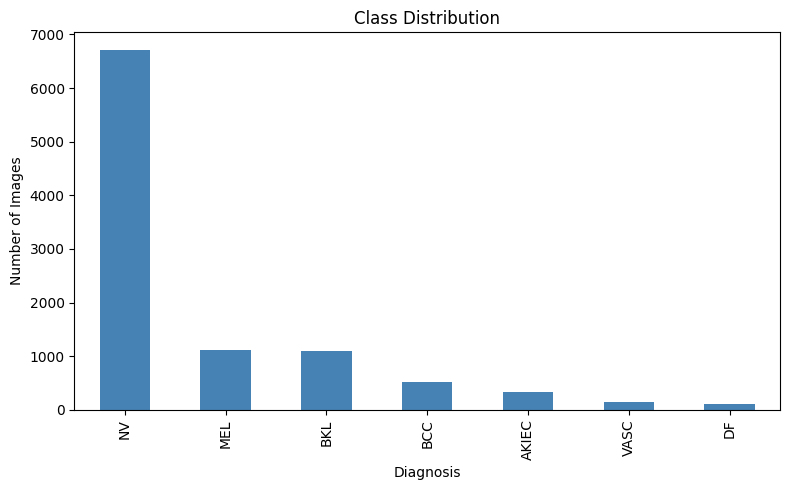

In [4]:
label_cols = [c for c in df.columns if c not in ("image", "image_id", "lesion_id")]

if len(label_cols) > 1 and df[label_cols].isin([0, 1]).all().all():
    # one-hot encoded format (e.g. ISIC GroundTruth.csv)
    class_counts = df[label_cols].sum().sort_values(ascending=False)
    df["label"] = df[label_cols].idxmax(axis=1)
else:
    # single label column (e.g. "dx")
    label_col = label_cols[0]
    df = df.rename(columns={label_col: "label"})
    class_counts = df["label"].value_counts()

print(class_counts)

class_counts.plot(kind="bar", color="steelblue")
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=150)
plt.show()


## 4. Sample images per class

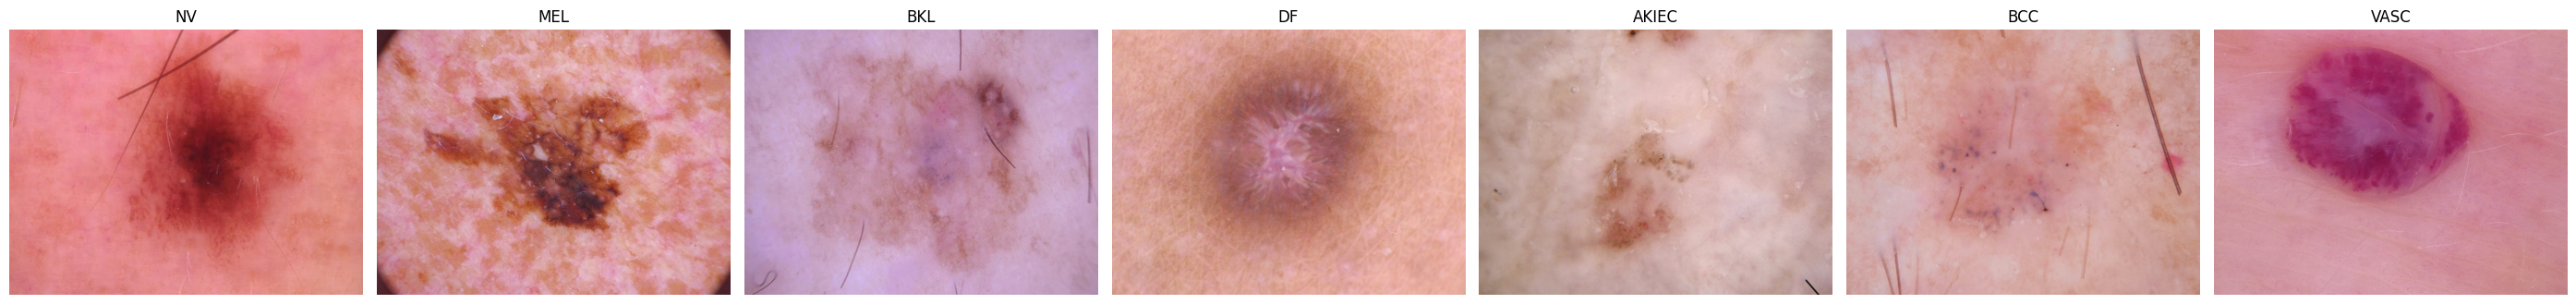

In [5]:
image_col = "image"
classes = df["label"].unique()

fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    sample_id = df[df["label"] == cls][image_col].iloc[0]
    img_path = os.path.join(IMAGES_DIR, f"{sample_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(IMAGES_DIR, f"{sample_id}.png")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_images_per_class.png"), dpi=150)
plt.show()


## 5. Image properties (size & color mode)

In [ ]:
sample_files = os.listdir(IMAGES_DIR)[:20]
sizes = []

for f in sample_files:
    img = Image.open(os.path.join(IMAGES_DIR, f))
    sizes.append(img.size)  # (width, height)

widths, heights = zip(*sizes)
print(f"Checked {len(sample_files)} images")
print(f"Width  -> min: {min(widths)}, max: {max(widths)}")
print(f"Height -> min: {min(heights)}, max: {max(heights)}")
print(f"Color mode (first image): {Image.open(os.path.join(IMAGES_DIR, sample_files[0])).mode}")


Checked 20 images
Width  -> min: 600, max: 600
Height -> min: 450, max: 450
Color mode (first image): RGB


## 6. Masks check (optional)

In [7]:
if os.path.isdir(MASKS_DIR):
    n_images = len(os.listdir(IMAGES_DIR))
    n_masks = len(os.listdir(MASKS_DIR))
    print(f"Images: {n_images}, Masks: {n_masks}")
else:
    print("No masks folder found.")


Images: 10016, Masks: 10015


## 7. Summary

In [8]:
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print(f"Class imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}")


Total images: 10015
Number of classes: 7
Class imbalance ratio (max/min): 58.30
